### Importación de librerías

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

### Carga de datos

##### Dataset con todas las variables

In [21]:
df_adop_all = pd.read_csv("../data/Clean/pet_adoption_data_clean_all.csv")

In [22]:
df_adop_all.columns

Index(['WeightKg', 'Vaccinated', 'HealthCondition', 'TimeInShelterDays',
       'AdoptionFee', 'PreviousOwner', 'target', 'AgeYears', 'PetType_Bird',
       'PetType_Cat', 'PetType_Dog', 'PetType_Rabbit',
       'Breed_Golden Retriever', 'Breed_Labrador', 'Breed_Parakeet',
       'Breed_Persian', 'Breed_Poodle', 'Breed_Rabbit', 'Breed_Siamese',
       'Color_Black', 'Color_Brown', 'Color_Gray', 'Color_Orange',
       'Color_White', 'Size_Large', 'Size_Medium', 'Size_Small'],
      dtype='object')

##### Dataset con variables correladas con target

In [23]:
df_adop_corr = pd.read_csv("../data/Clean/pet_adoption_data_clean_corr.csv")

In [24]:
df_adop_corr.columns

Index(['Vaccinated', 'HealthCondition', 'target', 'AgeYears', 'PetType_Bird',
       'PetType_Cat', 'PetType_Dog', 'PetType_Rabbit',
       'Breed_Golden Retriever', 'Breed_Labrador', 'Breed_Parakeet',
       'Breed_Persian', 'Breed_Poodle', 'Breed_Rabbit', 'Breed_Siamese',
       'Size_Large', 'Size_Medium', 'Size_Small'],
      dtype='object')

### Modelo 1: Logistic Regression

##### 1. Modelo con todas las variables (df_adop_all)

In [25]:
X = df_adop_all.drop(["target"], axis = 1)
y = df_adop_all["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##### Escalado de variables numéricas

In [26]:
numericas = ["WeightKg", "TimeInShelterDays", "AdoptionFee", "AgeYears"]

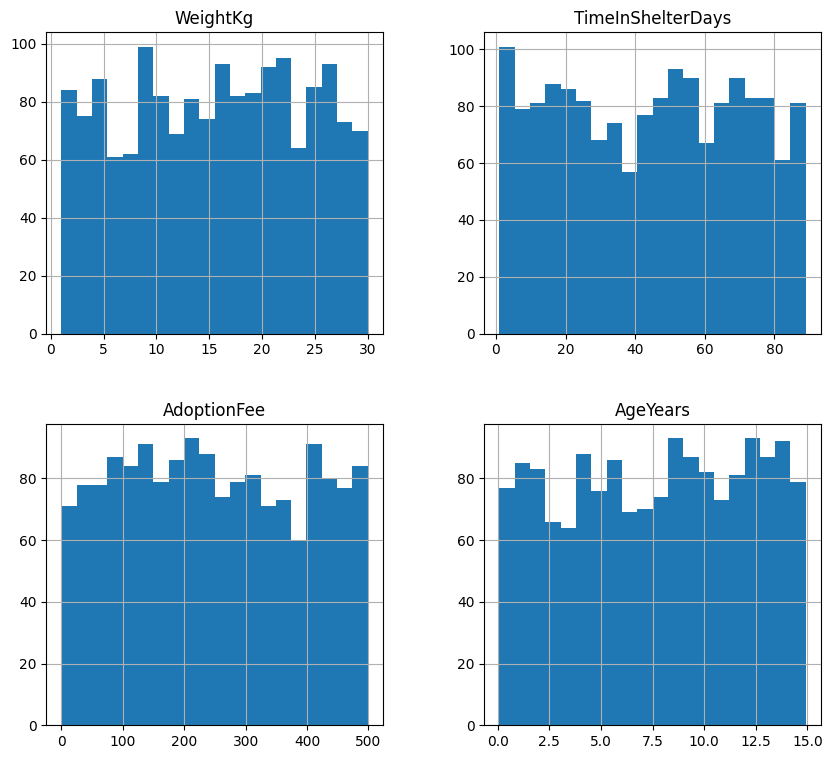

In [27]:
X_train[numericas].hist(bins=20, figsize=(10, 9)) 
plt.show()

- Distribuciones centradas 
- Ausencia de colas extremas o asimetrías
- No hay picos raros ni outliers

No hay que hacerle ninguna transformación a las variables numéricas (salvo escalado)

In [28]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
#std_scaler.fit(train_set[features_num])

resultado_standardization = pd.DataFrame(std_scaler.fit_transform(X_train[numericas]),columns = numericas)
resultado_standardization.head()

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
0,-0.063029,1.156743,1.194905,-0.460397
1,1.072712,-0.008836,1.118218,1.540997
2,-0.569898,-0.047688,0.874212,1.483220
3,-1.541307,0.224280,0.658093,0.829185
4,1.369637,1.117890,-1.342755,1.483220


In [29]:
# Estandarización:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train[numericas])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


##### Transformación en train y test

In [30]:
X_train[numericas] = scaler.transform(X_train[numericas])
X_test[numericas] = scaler.transform(X_test[numericas])

In [31]:
X_train[numericas].describe()

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
count,1.605000e+03,1.605000e+03,1.605000e+03,1.605000e+03
mean,-4.980440e-17,3.541646e-17,1.881499e-17,1.770823e-16
std,1.000312e+00,1.000312e+00,1.000312e+00,1.000312e+00
min,-1.764517e+00,-1.679498e+00,-1.726193e+00,-1.752290e+00
25%,-8.256426e-01,-9.024457e-01,-8.547437e-01,-8.463472e-01
50%,3.152828e-02,3.001697e-02,-5.998179e-02,3.879588e-02
75%,8.392820e-01,8.459218e-01,8.532973e-01,8.869617e-01
max,1.740574e+00,1.739532e+00,1.752633e+00,1.677351e+00


In [32]:
X_test[numericas].describe()

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
count,402.000000,402.000000,402.000000,402.000000
mean,0.061282,-0.049138,0.053541,0.032150
std,1.035172,0.999413,0.979420,1.021099
min,-1.762270,-1.679498,-1.712250,-1.752290
25%,-0.839195,-0.980151,-0.776313,-0.864836
50%,0.090047,-0.008836,0.117794,0.117373
75%,0.991820,0.807069,0.950900,0.926250
max,1.740952,1.739532,1.738690,1.677351


##### Preparación previa al modelo

En este caso, la variable objetivo es una variable binaria. En la observación de los datos (notebook_EDA), se aprecia desbalance entre la no adopción (0, más frecuente) con respecto a las adopcion (1). Por ello, voy a comprobar el porcentaje de desbalanceo que existe, para aplicarle el balanceo al crear el modelo.

In [33]:
# Comprobación del porcentaje de desbalanceo entre categorías:
y_train.value_counts(normalize = True)

target
0    0.671651
1    0.328349
Name: proportion, dtype: float64

Con el porcentaje obtenido, se observa un claro desbalance entre categorías. Esto, en cuanto al modelo, puede provocar que éste se incline hacia la categoría mayoritaria, no aprendiendo nada útil sobre las adopciones. Por ello, aplico class_weight = balanced, para paliar esta desigualdad entre clases.

In [34]:
log_reg = LogisticRegression (max_iter = 5000, class_weight = "balanced")
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

##### Interpretación de los pesos

In [35]:
print(log_reg.coef_, "\n")
print(log_reg.intercept_, "\n")
print(log_reg.classes_)

[[ 0.01184647  2.71793026 -2.85959062  0.01049494 -0.09494851 -0.09497115
  -0.6722122  -0.20976401 -0.32592968  0.77098208 -0.23738604 -0.69221342
   1.83423158 -0.20976401 -0.43793204 -0.37103607 -0.23738604  0.11200236
   0.12879984 -0.02217399 -0.11805211  0.09843253 -0.08910392 -1.13073234
   2.03064215 -0.90200745]] 

[-2.02405441] 

[0 1]


- log_reg.coef_ : Los coeficientes en positivo, indican aumento la probabilidad de adopción, frente a los negativos, que la disminuyen.

- log_reg.intercept_ : Al obtener un valor negativo, el modelo tiende a predecir la "no adopción" dado que es la clase dominante de la variable.

- log_reg.classes_ : Orden en el que el modelo está trabajando. Relacionado con la variable target, por eso [0 1]

In [36]:
# Visualización más clara de los coeficientes:

coef= pd.Series(log_reg.coef_[0], index = X_train.columns)

coef_df = pd.DataFrame(coef.sort_values(ascending=False), columns=['Coefficient'])
coef_df

,Coefficient
Vaccinated,2.717930
Size_Medium,2.030642
Breed_Labrador,1.834232
PetType_Dog,0.770982
Color_Black,0.128800
Breed_Siamese,0.112002
Color_Orange,0.098433
WeightKg,0.011846
TimeInShelterDays,0.010495
Color_Brown,-0.022174


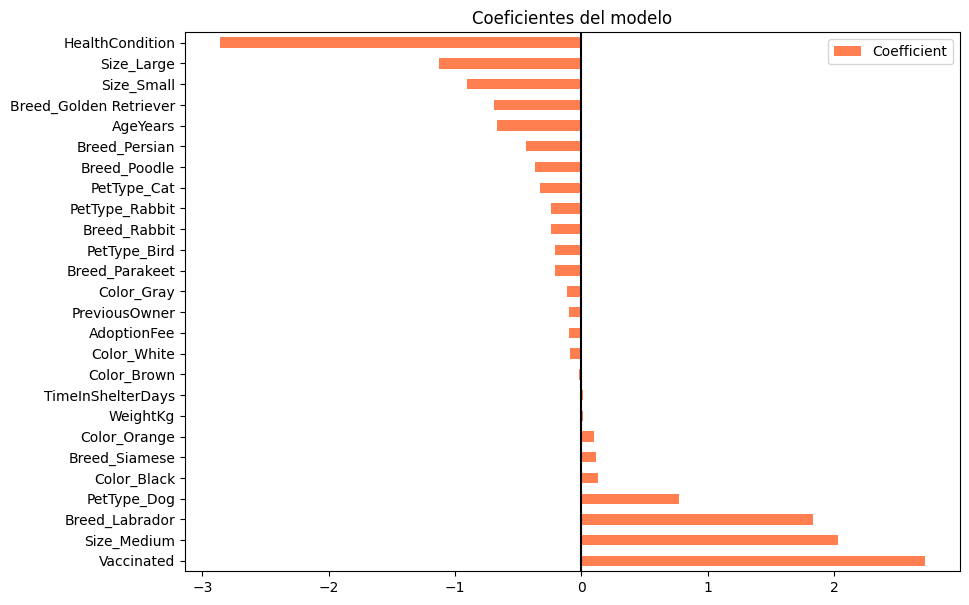

In [42]:
coef_df.plot(kind="barh", figsize=(10, 7), color="coral")
plt.axvline(0, color="black")
plt.title("Coeficientes del modelo")
plt.show()